In [1]:
import cafe

# cafe.logger.setLevel("INFO")
cafe.logger.setLevel("DEBUG")

# cafe.settings.backend = "python_function"
cafe.settings.backend = "conda"
# cafe.settings.backend = "cfe_docker"

cafe.settings.save_external_data = True # save external data
cafe.settings.save_h5ad = True # save external data

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.5_velocity_kernel.h5ad'...                                                                                       
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 2531 × 5974
    obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'raw_index'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'T_fwd_params', 'clusters_colors', 'clusters_fine_colors', 'louvain_Alpha_colors', 'louvain_Beta_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'id', 'cafe', 'filename'
    obsm: 'T_fwd_umap', 'X_pca', 'X_umap'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'spliced

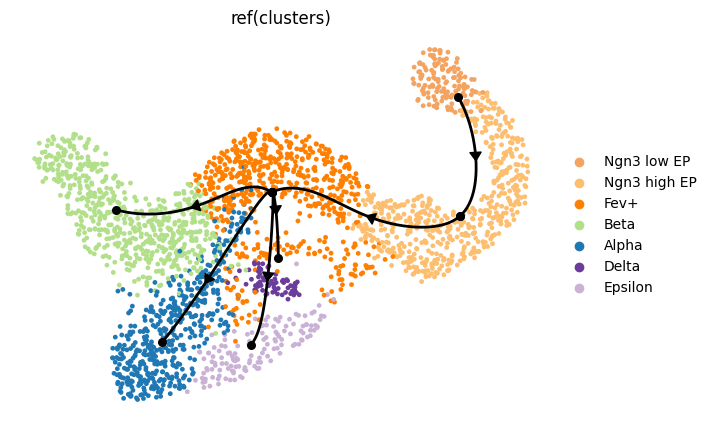

In [2]:
fadata = cafe.data.read_pancreas_cellrank()
# cafe.plot.plot_embedding_plotly(fadata) # interactive plotly plot and mannually 
cafe.plot.plot_trajectory(fadata)
fadata

In [3]:
method2parameters = {
    # "scvelo": {},
    # "dynamo": {},
    # "palantir": {},
    # "cytotrace2": {
    #     "max_cores": 8,        # 减少并行核心数，降低内存使用
    #     "batch_size": 1024,    # 减小批处理大小
    # },
    # "veloae": {},
    # "pyrovelocity": {
    #     "configuration_kwargs": {
    #         "training_configuration_1":{
    #             "batch_size": 1024,  # 减小批处理大小
    #             "max_epochs": 50,    # 减少训练轮数
    #         }
    #     }
    # }, # TODO: 这里传参要优化一下
    "stavia": {},
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = True # use common preprocessing
    parameters["benchmark_resource"] = True # record resource usage
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'stavia' is available: Python 3.10.14                                                                                                                                   
DEBUG    |- Loaded function 'stavia': <function stavia at 0x7f2f44c4c430>                                                                                                                               
INFO     |- method backend loaded: CondaBackend: stavia in conda env 'stavia'                                                                                                                           
DEBUG    |- set new log file: .cafe/pancreas_cellrank/log/20251210_211735__stavia-conda__Elm2Tv1QvU.log                                                                                             

DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- plot_trajectory for model_name:'20251210_211735__stavia-conda__Elm2Tv1QvU', color:'clusters'                                                                                                
DEBUG    |- plot_trajectory for model_name:'20251210_211735__stavia-conda__Elm2Tv1QvU', color:'milestone'                                                                                               
WARNING  |- milestone cell color length not equal to cell number! set missing color as '#808080'.                                                                                                       


array([[<Axes: title={'center': 'stavia-conda(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'stavia-conda(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

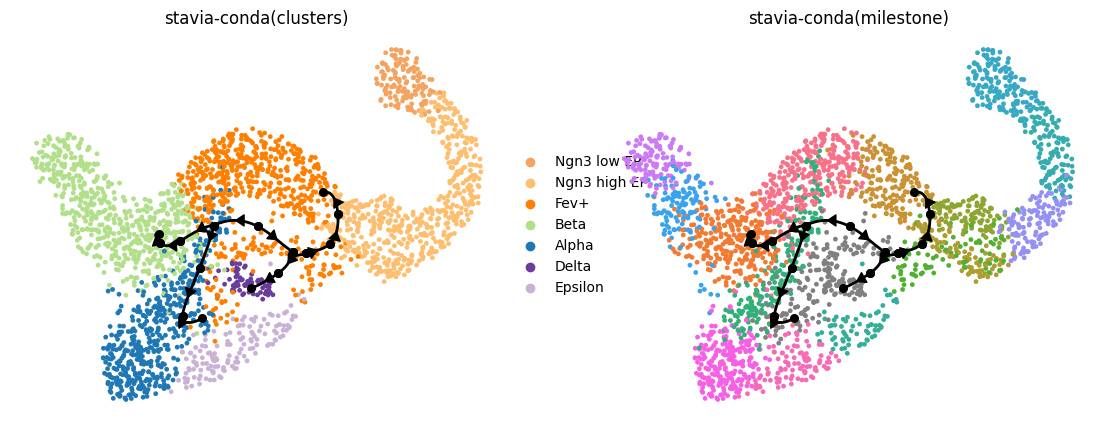

In [6]:
model_name_list = fadata.get_all_model_name(parse=False)
model_name_list.remove("ref")  # remove ref trajectory
color_list = ["clusters", "milestone"]

cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [7]:
fadata.write_trajectory_dict()

DEBUG    |- write trajectory 'ref' to '.cafe/pancreas_cellrank/trajectory_history/ref.pkl'                                                                                                              


DEBUG    |- write trajectory '20251210_211735__stavia-conda__Elm2Tv1QvU' to '.cafe/pancreas_cellrank/trajectory_history/20251210_211735__stavia-conda__Elm2Tv1QvU.pkl'                                  
